# 05 — Environment Comparison: Windows Local vs Colab/Linux Runtime

**Benchmark:** Benchmark 4 — Real Data Environment Comparison  
**Scope:** Real Amazon Reviews benchmark, Windows local vs Colab/Linux runtime.  
**Frameworks:** Pandas, Polars eager, Polars lazy, Dask.  
**Important environment note:** Windows was run on a local machine with about **16 GB RAM**. Colab/Linux was run on a cloud runtime with about **12 GB RAM** and stricter runtime constraints.

Notebook này không chạy benchmark workload. Notebook chỉ đọc kết quả đã có trong `results/raw/` và kiểm tra mức độ nhạy của benchmark với môi trường chạy.

Vì hai môi trường khác nhau không chỉ ở OS mà còn ở RAM, CPU allocation, runtime policy, background load, timeout/OOM policy, filesystem behavior, và cách Colab quản lý tài nguyên, notebook này được diễn giải là **environment comparison: Windows local vs Colab/Linux runtime**. Đây không phải pure Windows-vs-Linux operating-system benchmark. Đặc biệt, mốc `50M` trên Colab/Linux không có runtime hoàn chỉnh, nên không được dùng để so sánh tốc độ.

## 1. Research Questions

Notebook này trả lời năm câu hỏi chính:

1. Với các mốc có đủ dữ liệu (`1M`, `10M`), ranking giữa framework có ổn định giữa Windows local và Colab/Linux runtime không?
2. Runtime và peak memory khác nhau như thế nào giữa hai môi trường chạy cụ thể này?
3. Workload nào nhạy nhất với môi trường chạy?
4. Việc Colab/Linux không hoàn thành `50M` nói gì về robustness, scalability, memory pressure, hoặc runtime constraints?
5. Kết quả này nên được đưa vào report như thế nào để không bị hiểu nhầm là Linux chậm hơn Windows?

## 2. Methodology Boundary

Benchmark này là **end-to-end dataframe analytics benchmark**. Runtime bao gồm đọc parquet, execute workload, memory allocation, materialization, OS cache, pagefile/swap behavior, memory pressure, và runtime policy.

Vì vậy, nếu một workload `50M` chạy được trên Windows local nhưng không hoàn thành trên Colab/Linux runtime, đó là một kết quả thực tế quan trọng về **resource sensitivity**. Tuy nhiên, nó không được dùng để kết luận rằng Linux chậm hơn Windows. Kết quả này phản ánh sự khác nhau của môi trường thực thi cụ thể: local Windows machine vs managed Colab/Linux runtime.

In [17]:
import pandas as pd

comparison_boundary = pd.DataFrame([
    {
        "comparison": "Windows local vs Colab/Linux runtime at 1M and 10M",
        "validity": "valid with caveat",
        "interpretation": "Environment comparison on completed runs; hardware and resource policies differ.",
    },
    {
        "comparison": "Windows 50M runtime vs missing Colab/Linux 50M runtime",
        "validity": "invalid as speed comparison",
        "interpretation": "Treat Colab/Linux 50M as incomplete-run/stability observation, likely related to memory pressure or runtime constraints.",
    },
    {
        "comparison": "Windows local vs Colab/Linux as pure OS comparison",
        "validity": "invalid in this setup",
        "interpretation": "Pure OS comparison requires the same physical hardware and comparable resource limits.",
    },
    {
        "comparison": "Framework robustness under constrained Colab/Linux runtime",
        "validity": "valid",
        "interpretation": "Missing or terminated large runs indicate sensitivity to memory limits, materialization behavior, and managed runtime constraints.",
    },
])

display(comparison_boundary)

,comparison,validity,interpretation
0,Windows local vs Colab/Linux runtime at 1M and...,valid with caveat,Environment comparison on completed runs; hard...
1,Windows 50M runtime vs missing Colab/Linux 50M...,invalid as speed comparison,Treat Colab/Linux 50M as incomplete-run/stabil...
2,Windows local vs Colab/Linux as pure OS compar...,invalid in this setup,Pure OS comparison requires the same physical ...
3,Framework robustness under constrained Colab/L...,valid,Missing or terminated large runs indicate sens...


## 3. Setup and Data Loading

Code dùng key và tên biến tiếng Anh để khớp với CSV benchmark. Nội dung markdown dùng tiếng Việt để giải thích kết quả.

In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "analysis", "report", "data_prep"}:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

RAW_DIR = PROJECT_ROOT / "results" / "raw"
PLOT_DIR = PROJECT_ROOT / "results" / "figures" / "05_real_env_comparison"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

WINDOWS_FILES = [
    "pandas_real_results.csv",
    "polars_real_results.csv",
    "polars_eager_real_results.csv",
    "dask_real_results.csv",
]

COLAB_FILES = [
    "pandas_colab_results.csv",
    "polars_colab_results.csv",
    "polars_eager_colab_results.csv",
    "dask_colab_results.csv",
]

ROW_ORDER = ["1M", "10M"]
WORKLOAD_ORDER = ["filter", "groupby", "join", "pipeline"]
FRAMEWORK_ORDER = ["pandas", "polars_eager", "polars_lazy", "dask"]
ENV_ORDER = ["windows_local_16gb", "colab_linux_12gb"]

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

In [19]:
def load_environment(files, environment):
    frames = []
    missing = []
    for name in files:
        path = RAW_DIR / name
        if not path.exists():
            missing.append(name)
            continue
        frame = pd.read_csv(path)
        frame["environment"] = environment
        frame["source_file"] = name
        frames.append(frame)
    return frames, missing


windows_frames, missing_windows = load_environment(WINDOWS_FILES, "windows_local_16gb")
colab_frames, missing_colab = load_environment(COLAB_FILES, "colab_linux_12gb")

missing_files = missing_windows + missing_colab
if missing_files:
    print("Missing files:", missing_files)

if not windows_frames or not colab_frames:
    raise FileNotFoundError("Both Windows/local and Colab/Linux result files are required for this notebook.")

df_raw = pd.concat(windows_frames + colab_frames, ignore_index=True)
df_raw["dataset_size"] = pd.Categorical(df_raw["dataset_size"], ROW_ORDER, ordered=True)
df_raw["workload"] = pd.Categorical(df_raw["workload"], WORKLOAD_ORDER, ordered=True)
df_raw["framework"] = pd.Categorical(df_raw["framework"], FRAMEWORK_ORDER, ordered=True)
df_raw["environment"] = pd.Categorical(df_raw["environment"], ENV_ORDER, ordered=True)

print(f"Loaded {len(df_raw):,} benchmark rows from {df_raw['source_file'].nunique()} files.")
display(
    df_raw
    .groupby(["environment", "source_file"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)

Loaded 240 benchmark rows from 8 files.


,environment,source_file,rows
0,windows_local_16gb,dask_real_results.csv,36
1,windows_local_16gb,pandas_real_results.csv,36
2,windows_local_16gb,polars_eager_real_results.csv,36
3,windows_local_16gb,polars_real_results.csv,36
4,colab_linux_12gb,dask_colab_results.csv,24
5,colab_linux_12gb,pandas_colab_results.csv,24
6,colab_linux_12gb,polars_colab_results.csv,24
7,colab_linux_12gb,polars_eager_colab_results.csv,24


### Data Availability by Environment

**Observation:**  
Bảng trên cho thấy số lượng dòng kết quả giữa hai môi trường không bằng nhau. Với môi trường **Windows local 16GB**, mỗi file kết quả có **36 dòng**, trong khi với môi trường **Colab/Linux 12GB**, mỗi file chỉ có **24 dòng**.

**Reason:**  
Sự khác biệt này xảy ra vì môi trường Colab không chạy hoặc không hoàn thành được benchmark với kích thước dữ liệu **50M rows**. Do đó, kết quả trên Colab chỉ bao gồm các dataset size nhỏ hơn, chủ yếu là **1M** và **10M**, trong khi Windows local có thêm các kết quả cho **50M**.

**Interpretation:**  
Điều này cho thấy dữ liệu benchmark giữa hai môi trường không hoàn toàn cân bằng ở tất cả các kích thước dữ liệu. Vì vậy, khi so sánh trực tiếp giữa Windows và Colab, chỉ nên sử dụng các dataset size mà cả hai môi trường đều có kết quả hoàn chỉnh.

**Implication for Analysis:**  
Các phân tích so sánh trực tiếp về runtime, memory và throughput giữa hai môi trường nên tập trung vào các kích thước dữ liệu chung, cụ thể là **1M** và **10M**. Phần **50M** nên được xem như một quan sát riêng về khả năng hoàn thành workload dưới giới hạn tài nguyên của từng môi trường, thay vì dùng để so sánh hiệu năng trực tiếp.

## 4. Data Completeness and Incomplete-Run Scope

`status == "ok"` được dùng cho runtime/memory comparison. Các tổ hợp không có dữ liệu, đặc biệt `50M` trên Colab/Linux runtime, được phân tích riêng như incomplete-run/stability observation.

In [20]:
df_ok = df_raw[df_raw["status"] == "ok"].copy()
df_fail = df_raw[df_raw["status"] != "ok"].copy()

run_count = (
    df_raw
    .groupby(["environment", "framework", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
)

display(run_count)

,environment,framework,workload,dataset_size,status,n_runs
0,windows_local_16gb,pandas,filter,1M,ok,3
1,windows_local_16gb,pandas,filter,10M,ok,3
2,windows_local_16gb,pandas,groupby,1M,ok,3
3,windows_local_16gb,pandas,groupby,10M,ok,3
4,windows_local_16gb,pandas,join,1M,ok,3
...,...,...,...,...,...,...
59,colab_linux_12gb,dask,groupby,10M,ok,3
60,colab_linux_12gb,dask,join,1M,ok,3
61,colab_linux_12gb,dask,join,10M,ok,3
62,colab_linux_12gb,dask,pipeline,1M,ok,3


In [21]:
observed_success = (
    df_ok
    .groupby(["environment", "framework", "workload", "dataset_size"], observed=True)
    .size()
    .rename("successful_runs")
    .reset_index()
)

expected = pd.MultiIndex.from_product(
    [ENV_ORDER, FRAMEWORK_ORDER, WORKLOAD_ORDER, ROW_ORDER],
    names=["environment", "framework", "workload", "dataset_size"],
).to_frame(index=False)

completeness = expected.merge(
    observed_success,
    on=["environment", "framework", "workload", "dataset_size"],
    how="left",
)
completeness["successful_runs"] = completeness["successful_runs"].fillna(0).astype(int)
completeness["completion_status"] = np.where(completeness["successful_runs"] > 0, "ok", "missing_or_not_completed")

missing_observations = completeness[completeness["completion_status"] != "ok"].copy()
missing_observations["interpretation"] = np.where(
    (missing_observations["environment"] == "colab_linux_12gb") & (missing_observations["dataset_size"] == "50M"),
    "Colab/Linux run did not complete; based on memory trend and smaller available RAM, this is likely related to memory pressure or runtime constraints. No runtime is reported.",
    "No successful run is present in the raw result files.",
)

completion_matrix = completeness.pivot_table(
    index=["environment", "framework", "workload"],
    columns="dataset_size",
    values="successful_runs",
    observed=True,
    fill_value=0,
)

display(completion_matrix)
display(missing_observations)

dataset_size                              10M   1M
environment        framework    workload          
colab_linux_12gb   dask         filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   pandas       filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   polars_eager filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   polars_lazy  filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
windows_local_16gb dask         filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   pandas       filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   polars_eager filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0
                   polars_lazy  filter    3.0  3.0
                                groupby   3.0  3.0
                                join      3.0  3.0
                                pipeline  3.0  3.0

,environment,framework,workload,dataset_size,successful_runs,completion_status,interpretation


### Completeness Interpretation

**Observation:**  
Bảng completeness cho thấy với hai kích thước dữ liệu chung là **1M** và **10M**, tất cả các tổ hợp giữa `environment`, `framework` và `workload` đều có giá trị **3.0**.

**Environment Coverage:**  
Cả **Windows local 16GB** và **Colab/Linux 12GB** đều có đầy đủ kết quả cho tất cả framework gồm `pandas`, `polars_eager`, `polars_lazy` và `dask`, cũng như tất cả workload gồm `filter`, `groupby`, `join` và `pipeline`.

**Interpretation:**  
Vì tất cả các giá trị đều bằng **3.0**, có thể xem các benchmark ở mức **1M** và **10M** là hợp lệ để so sánh trực tiếp giữa hai môi trường. Sự đầy đủ này giúp giảm rủi ro sai lệch do thiếu lần chạy hoặc thiếu workload.

**Note:**  
Bảng này chỉ phản ánh các dataset size xuất hiện trong phần so sánh chung giữa hai môi trường, cụ thể là **1M** và **10M**. Kích thước **50M** không xuất hiện ở đây vì Colab không có kết quả hoàn chỉnh cho mức dữ liệu này, nên không phù hợp để đưa vào bảng completeness dùng cho so sánh trực tiếp.

**Implication for Analysis:**  
Các phân tích tiếp theo về runtime, memory usage và throughput giữa Windows và Colab nên dựa trên hai kích thước dữ liệu **1M** và **10M**, vì đây là các mức có dữ liệu đầy đủ, cân bằng và có thể so sánh công bằng giữa hai môi trường.

## 5. Aggregated Results

Bảng `summary` là nguồn chính cho các phân tích tiếp theo. Mỗi tổ hợp được tổng hợp bằng mean, standard deviation, và số successful runs.

In [22]:
summary = (
    df_ok
    .groupby(["environment", "framework", "workload", "dataset_size"], observed=True)
    .agg(
        mean_time_s=("time_s", "mean"),
        std_time_s=("time_s", "std"),
        mean_peak_memory_mb=("peak_memory_mb", "mean"),
        std_peak_memory_mb=("peak_memory_mb", "std"),
        mean_throughput_rows_per_s=("throughput_rows_per_s", "mean"),
        std_throughput_rows_per_s=("throughput_rows_per_s", "std"),
        mean_n_rows=("n_rows", "mean"),
        successful_runs=("run_index", "count"),
    )
    .reset_index()
)

summary["mean_time_min"] = summary["mean_time_s"] / 60
summary["mean_peak_memory_gb"] = summary["mean_peak_memory_mb"] / 1024
summary["throughput_mrows_per_s"] = summary["mean_throughput_rows_per_s"] / 1_000_000
summary["runtime_cv"] = summary["std_time_s"] / summary["mean_time_s"]

display(
    summary
    .sort_values(["environment", "dataset_size", "workload", "framework"])
    .round(3)
)

,environment,framework,workload,dataset_size,mean_time_s,std_time_s,mean_peak_memory_mb,std_peak_memory_mb,mean_throughput_rows_per_s,std_throughput_rows_per_s,mean_n_rows,successful_runs,mean_time_min,mean_peak_memory_gb,throughput_mrows_per_s,runtime_cv
0,windows_local_16gb,pandas,filter,1M,2.052,0.045,1356.333,13.807,487402.667,10562.018,1000000.0,3,0.034,1.325,0.487,0.022
8,windows_local_16gb,polars_eager,filter,1M,0.317,0.008,763.840,63.886,3155034.000,79804.987,1000000.0,3,0.005,0.746,3.155,0.026
16,windows_local_16gb,polars_lazy,filter,1M,0.371,0.003,688.360,16.613,2696172.000,20903.454,1000000.0,3,0.006,0.672,2.696,0.008
24,windows_local_16gb,dask,filter,1M,0.692,0.012,1006.843,36.851,1446202.333,24508.972,1000000.0,3,0.012,0.983,1.446,0.017
2,windows_local_16gb,pandas,groupby,1M,2.634,0.067,1381.780,8.836,379822.333,9739.419,1000000.0,3,0.044,1.349,0.380,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,colab_linux_12gb,dask,join,10M,15.632,0.570,4619.707,57.158,640280.667,22960.169,10000000.0,3,0.261,4.511,0.640,0.036
39,colab_linux_12gb,pandas,pipeline,10M,37.381,0.454,6813.487,36.341,267540.333,3262.125,10000000.0,3,0.623,6.654,0.268,0.012
47,colab_linux_12gb,polars_eager,pipeline,10M,7.195,0.271,5237.383,24.129,1391253.333,51925.688,10000000.0,3,0.120,5.115,1.391,0.038
55,colab_linux_12gb,polars_lazy,pipeline,10M,4.979,0.380,2110.753,419.986,2016517.333,155406.182,10000000.0,3,0.083,2.061,2.017,0.076


### Summary Interpretation

**Observation:**  
Bảng `summary` gồm **64 dòng** và **16 cột**, tổng hợp kết quả benchmark theo từng tổ hợp của `environment`, `framework`, `workload` và `dataset_size`. Mỗi dòng đại diện cho kết quả trung bình của một benchmark case sau **3 lần chạy thành công**. :contentReference[oaicite:0]{index=0}

**Included Metrics:**  
Bảng này bao gồm các chỉ số chính như:

- `mean_time_s`: thời gian chạy trung bình tính bằng giây.
- `std_time_s`: độ lệch chuẩn của thời gian chạy.
- `mean_peak_memory_mb`: bộ nhớ đỉnh trung bình tính bằng MB.
- `std_peak_memory_mb`: độ lệch chuẩn của bộ nhớ đỉnh.
- `mean_throughput_rows_per_s`: throughput trung bình theo số dòng xử lý mỗi giây.
- `successful_runs`: số lần chạy thành công.
- `mean_time_min`: thời gian chạy trung bình đổi sang phút.
- `mean_peak_memory_gb`: bộ nhớ đỉnh trung bình đổi sang GB.
- `throughput_mrows_per_s`: throughput đổi sang triệu dòng mỗi giây.
- `runtime_cv`: hệ số biến thiên runtime, dùng để đánh giá độ ổn định giữa các lần chạy.

**Data Scope:**  
Bảng summary hiện tập trung vào các kích thước dữ liệu có thể so sánh trực tiếp giữa hai môi trường, cụ thể là **1M** và **10M**. Với mỗi môi trường, có đầy đủ kết quả cho 4 framework gồm `pandas`, `polars_eager`, `polars_lazy` và `dask`, cùng 4 workload gồm `filter`, `groupby`, `join` và `pipeline`.

**Interpretation:**  
Vì mỗi benchmark case đều có `successful_runs = 3`, dữ liệu trong bảng summary có thể được xem là đủ ổn định để phân tích hiệu năng trung bình. Các chỉ số trung bình giúp so sánh tốc độ, mức sử dụng bộ nhớ và throughput giữa các framework, trong khi các chỉ số độ lệch chuẩn và `runtime_cv` giúp đánh giá mức độ dao động của kết quả.

**Implication for Analysis:**  
Bảng summary là nền tảng chính cho các phân tích tiếp theo, bao gồm so sánh runtime, memory usage, throughput và ranking framework. Tuy nhiên, khi so sánh giữa Windows local và Colab/Linux, nên chỉ dùng các dataset size có dữ liệu đầy đủ ở cả hai môi trường để đảm bảo tính công bằng.

## 6. Runtime Comparison on Completed Common Sizes

Phần này chỉ dùng `1M` và `10M`, vì đây là các row count có đủ dữ liệu ở cả Windows local và Colab/Linux runtime.

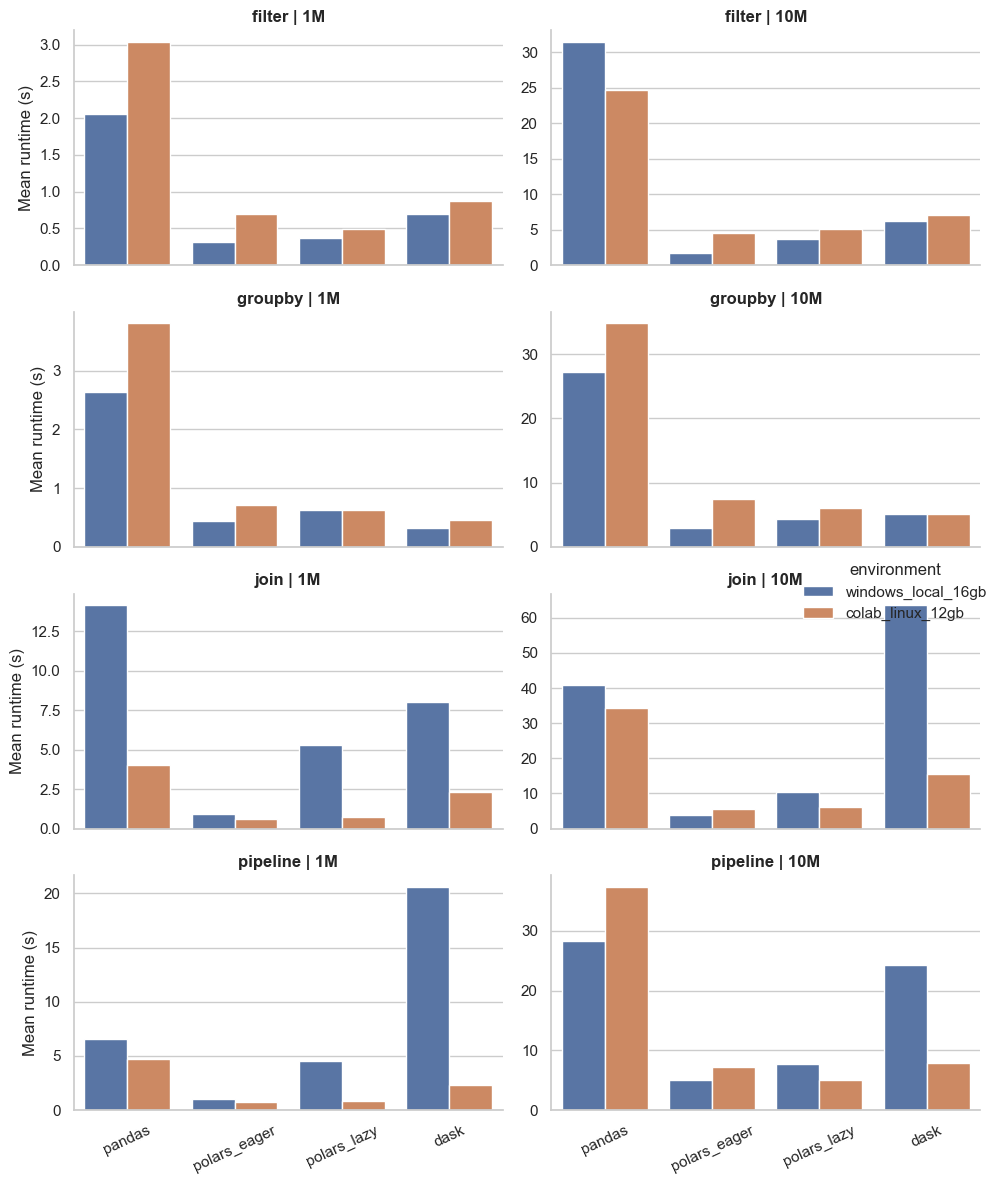

In [23]:
common_sizes = (
    summary
    .groupby(["framework", "workload", "dataset_size"], observed=True)["environment"]
    .nunique()
    .reset_index(name="n_environments")
)
common_sizes = common_sizes[common_sizes["n_environments"] == 2][["framework", "workload", "dataset_size"]]

common_summary = summary.merge(common_sizes, on=["framework", "workload", "dataset_size"], how="inner")

g = sns.catplot(
    data=common_summary,
    x="framework",
    y="mean_time_s",
    hue="environment",
    col="dataset_size",
    row="workload",
    kind="bar",
    order=FRAMEWORK_ORDER,
    hue_order=ENV_ORDER,
    sharey=False,
    height=3.0,
    aspect=1.35,
)
g.set_axis_labels("", "Mean runtime (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
g.figure.savefig(PLOT_DIR / "runtime_by_environment_common_runs.png", dpi=150, bbox_inches="tight")
plt.show()

### Runtime Comparison Interpretation

**Observation:**  
Biểu đồ so sánh `mean_time_s` giữa **Windows local 16GB** và **Colab/Linux 12GB** cho từng workload, dataset size và framework. Nhìn chung, hiệu năng không nghiêng hoàn toàn về một môi trường duy nhất, mà phụ thuộc vào loại workload và framework được sử dụng.

**Filter Workload:**  
Ở workload `filter`, các framework dựa trên Polars có runtime thấp nhất ở cả **1M** và **10M**. Với **10M**, `polars_eager` nhanh hơn rõ rệt so với `pandas` và `dask`. `pandas` có runtime cao nhất trong nhóm này, đặc biệt ở kích thước **10M**.

**Groupby Workload:**  
Ở workload `groupby`, `polars_eager`, `polars_lazy` và `dask` đều nhanh hơn đáng kể so với `pandas`. Khi tăng từ **1M** lên **10M**, runtime của `pandas` tăng mạnh, trong khi các framework còn lại tăng ít hơn. Điều này cho thấy Polars và Dask xử lý aggregation hiệu quả hơn trong benchmark này.

**Join Workload:**  
Ở workload `join`, sự khác biệt giữa hai môi trường thể hiện rõ hơn. Windows local có runtime cao hơn Colab ở một số trường hợp, đặc biệt với `pandas`, `polars_lazy` và `dask`. Với `dask`, Windows local có runtime rất cao ở cả **1M** và **10M**, cho thấy workload join có thể gây overhead lớn hơn trong môi trường Windows local.

**Pipeline Workload:**  
Ở workload `pipeline`, `polars_eager` và `polars_lazy` tiếp tục cho runtime thấp hơn so với `pandas` và `dask`. `dask` trên Windows local có runtime cao rõ rệt, đặc biệt ở **1M** và **10M**, trong khi Colab cho kết quả thấp hơn nhiều trong cùng workload. Điều này cho thấy pipeline tổng hợp có thể chịu ảnh hưởng lớn bởi overhead thực thi và môi trường chạy.

**Environment Comparison:**  
Colab không phải lúc nào cũng chậm hơn Windows dù có RAM thấp hơn. Ở một số workload như `join` và `pipeline`, Colab có runtime thấp hơn Windows đối với một vài framework. Ngược lại, trong các workload như `filter` và `groupby`, Windows có thể nhanh hơn ở một số trường hợp. Vì vậy, kết quả nên được hiểu là so sánh giữa **hai cấu hình môi trường cụ thể**, không phải kết luận tuyệt đối rằng hệ điều hành nào nhanh hơn.

**Key Takeaway:**  
`polars_eager` và `polars_lazy` nhìn chung là hai lựa chọn có runtime tốt và ổn định nhất trong phần lớn workload. `pandas` thường chậm hơn khi dữ liệu tăng lên **10M**, đặc biệt ở `filter`, `groupby` và `pipeline`. `dask` có hiệu năng không ổn định hơn, với một số trường hợp runtime cao đáng kể trên Windows local.

**Implication for Analysis:**  
Các kết quả này cho thấy việc chọn framework có ảnh hưởng lớn hơn nhiều so với chỉ chọn môi trường chạy. Khi làm việc với dữ liệu lớn, Polars cho thấy lợi thế rõ ràng về runtime, trong khi pandas phù hợp hơn với dữ liệu nhỏ hoặc các tác vụ đơn giản. Dask cần được đánh giá cẩn thận theo từng workload vì overhead có thể làm runtime tăng đáng kể trong một số trường hợp.

In [24]:
ratio_wide = (
    common_summary
    .pivot_table(
        index=["framework", "workload", "dataset_size"],
        columns="environment",
        values=["mean_time_s", "mean_peak_memory_mb"],
        observed=True,
    )
)

ratio = pd.DataFrame(index=ratio_wide.index)
ratio["windows_time_s"] = ratio_wide[("mean_time_s", "windows_local_16gb")]
ratio["colab_time_s"] = ratio_wide[("mean_time_s", "colab_linux_12gb")]
ratio["windows_memory_mb"] = ratio_wide[("mean_peak_memory_mb", "windows_local_16gb")]
ratio["colab_memory_mb"] = ratio_wide[("mean_peak_memory_mb", "colab_linux_12gb")]
ratio["windows_over_colab_time"] = ratio["windows_time_s"] / ratio["colab_time_s"]
ratio["windows_over_colab_memory"] = ratio["windows_memory_mb"] / ratio["colab_memory_mb"]
ratio = ratio.reset_index()

display(
    ratio
    .sort_values(["dataset_size", "workload", "framework"])
    .round(3)
)

,framework,workload,dataset_size,windows_time_s,colab_time_s,windows_memory_mb,colab_memory_mb,windows_over_colab_time,windows_over_colab_memory
0,pandas,filter,1M,2.052,3.040,1356.333,1201.160,0.675,1.129
8,polars_eager,filter,1M,0.317,0.701,763.840,615.573,0.452,1.241
16,polars_lazy,filter,1M,0.371,0.492,688.360,647.080,0.753,1.064
24,dask,filter,1M,0.692,0.880,1006.843,1389.413,0.786,0.725
2,pandas,groupby,1M,2.634,3.809,1381.780,1276.903,0.691,1.082
10,polars_eager,groupby,1M,0.435,0.706,829.133,695.237,0.615,1.193
18,polars_lazy,groupby,1M,0.624,0.622,1418.767,581.417,1.002,2.440
26,dask,groupby,1M,0.318,0.458,720.903,787.543,0.694,0.915
4,pandas,join,1M,14.170,4.031,2845.410,1312.983,3.515,2.167
12,polars_eager,join,1M,0.907,0.587,2124.097,639.113,1.546,3.324


### Ratio Interpretation

Bảng ratio được dùng để so sánh trực tiếp runtime và peak memory giữa **Windows local 16GB** và **Colab/Linux 12GB** trên cùng một tổ hợp `framework`, `workload` và `dataset_size`. Trong đó, `windows_over_colab_time > 1` nghĩa là Windows local chạy chậm hơn Colab/Linux, còn `windows_over_colab_time < 1` nghĩa là Windows local chạy nhanh hơn Colab/Linux trong cùng một benchmark case.

Kết quả cho thấy hiệu năng giữa hai môi trường không cố định theo một chiều. Ở một số workload như `filter` và `groupby`, Windows thường có runtime thấp hơn Colab, đặc biệt với các framework Polars. Tuy nhiên, ở các workload như `join` và `pipeline`, nhiều trường hợp Windows có ratio lớn hơn 1, nghĩa là Colab hoàn thành nhanh hơn trong các case đó.

Đối với memory ratio, phần lớn giá trị `windows_over_colab_memory` lớn hơn 1, cho thấy Windows local thường ghi nhận mức peak memory cao hơn Colab/Linux. Sự khác biệt này thể hiện rõ hơn ở các workload nặng như `join` và `pipeline`, nơi lượng dữ liệu trung gian và overhead xử lý có thể lớn hơn.

Các ratio này không nên được hiểu là thước đo thuần túy cho tốc độ của hệ điều hành. Chúng phản ánh đồng thời nhiều yếu tố như framework behavior, phần cứng, RAM khả dụng, filesystem, CPU allocation, OS cache, pagefile/swap, background load và Colab runtime policy. Vì vậy, ratio nên được đọc như một chỉ số về **environment sensitivity**, tức là mức độ nhạy của từng workload và framework đối với môi trường chạy.

Nói cách khác, một runtime thấp hơn trong một môi trường không nhất thiết có nghĩa là hệ điều hành của môi trường đó nhanh hơn. Nó chỉ cho thấy workload cụ thể đó hoàn thành nhanh hơn trong cấu hình thực nghiệm cụ thể được kiểm tra.

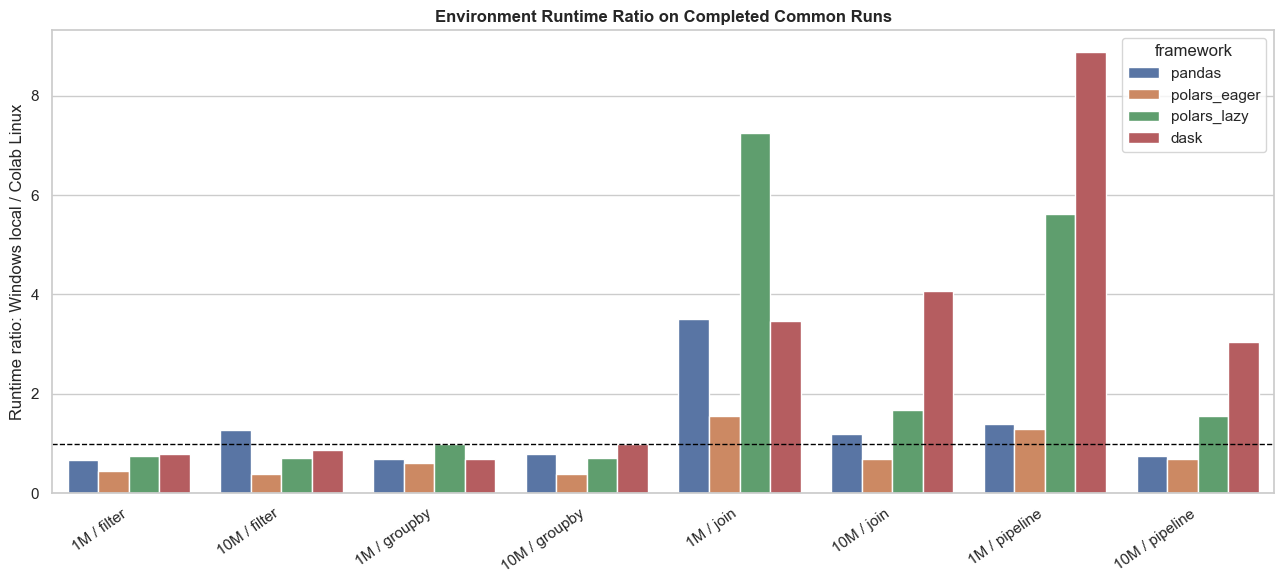

In [25]:
ratio_plot = ratio.copy()
ratio_plot["case"] = ratio_plot["dataset_size"].astype(str) + " / " + ratio_plot["workload"].astype(str)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=ratio_plot,
    x="case",
    y="windows_over_colab_time",
    hue="framework",
    hue_order=FRAMEWORK_ORDER,
)
plt.axhline(1.0, color="black", linewidth=1, linestyle="--")
plt.ylabel("Runtime ratio: Windows local / Colab Linux")
plt.xlabel("")
plt.title("Environment Runtime Ratio on Completed Common Runs")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "environment_runtime_ratio_common_runs.png", dpi=150, bbox_inches="tight")
plt.show()

### Completed-run Interpretation Guidance

Biểu đồ trên thể hiện tỷ lệ runtime `windows_over_colab_time`, tức là thời gian chạy trung bình trên **Windows local 16GB** chia cho thời gian chạy trung bình trên **Colab/Linux 12GB**, chỉ xét các benchmark case mà cả hai môi trường đều hoàn thành đầy đủ. Đường gạch ngang tại giá trị **1.0** là mốc so sánh: nếu cột nằm trên đường này thì Windows local chạy chậm hơn Colab trong case đó, còn nếu cột nằm dưới đường này thì Windows local chạy nhanh hơn Colab.

Kết quả cho thấy sự khác biệt runtime phụ thuộc rất mạnh vào workload và framework. Với các workload như `filter` và `groupby`, nhiều framework có tỷ lệ nhỏ hơn hoặc xấp xỉ 1, nghĩa là Windows local thường nhanh hơn hoặc tương đương Colab/Linux trong các case này. Tuy nhiên, với các workload nặng hơn như `join` và `pipeline`, một số framework có tỷ lệ lớn hơn 1 khá rõ rệt, đặc biệt là `polars_lazy` và `dask`. Điều này cho thấy các workload phức tạp hơn có mức độ nhạy cao hơn với môi trường chạy.

Ở workload `join`, Windows local chậm hơn Colab đáng kể trong nhiều trường hợp, đặc biệt với `polars_lazy` ở `1M` và `dask` ở cả `1M` lẫn `10M`. Tương tự, ở workload `pipeline`, `dask` và `polars_lazy` cũng cho tỷ lệ cao, cho thấy runtime trên Windows local lớn hơn nhiều so với Colab/Linux trong các case đó. Ngược lại, `polars_eager` thường có tỷ lệ thấp hơn hoặc gần 1 hơn, cho thấy framework này có hành vi ổn định hơn giữa hai môi trường trong nhiều workload.

Tuy nhiên, tỷ lệ runtime này không nên được hiểu là bằng chứng trực tiếp rằng hệ điều hành Windows nhanh hơn hay chậm hơn Linux. Một runtime thấp hơn trong một môi trường chỉ cho thấy workload cụ thể đó hoàn thành nhanh hơn trong cấu hình thực nghiệm cụ thể, bao gồm phần cứng, RAM khả dụng, CPU allocation, filesystem, OS cache, pagefile/swap, background load và chính sách runtime của Colab.

Vì vậy, kết quả `1M` và `10M` hữu ích để quan sát hành vi thực nghiệm giữa hai môi trường chạy thực tế, nhưng không nên dùng như kết luận về hiệu năng cấp hệ điều hành. Cách diễn giải hợp lý hơn là xem biểu đồ này như một chỉ báo về **environment sensitivity**, tức là mức độ mà từng framework và workload bị ảnh hưởng bởi môi trường thực thi.

## 7. Memory Comparison

Peak memory được đọc từ benchmark logs. Trên Colab/Linux, peak memory gần giới hạn runtime có thể dẫn tới termination thay vì pagefile-based slowdown như trên Windows.

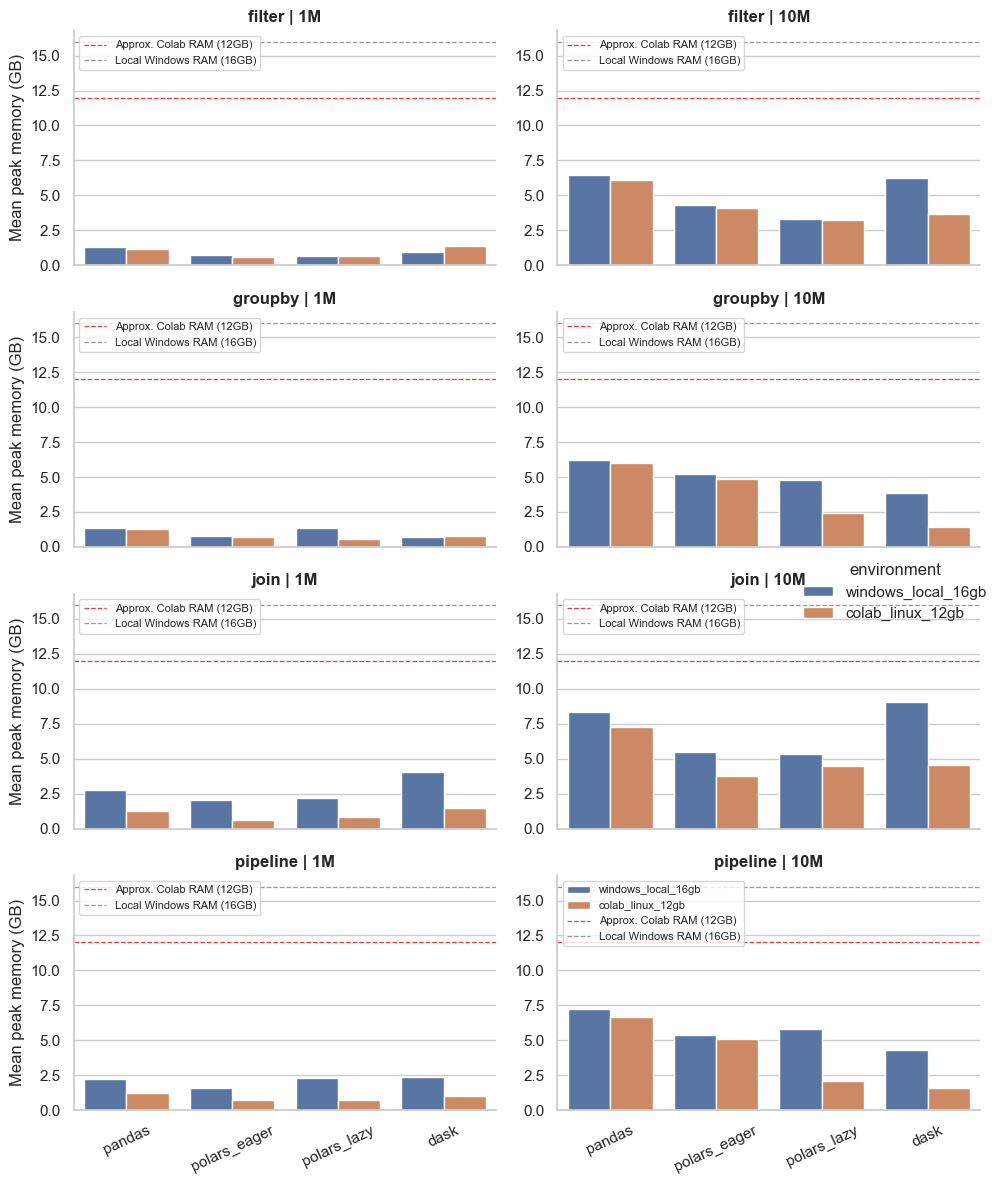

In [26]:
g = sns.catplot(
    data=common_summary,
    x="framework",
    y="mean_peak_memory_gb",
    hue="environment",
    col="dataset_size",
    row="workload",
    kind="bar",
    order=FRAMEWORK_ORDER,
    hue_order=ENV_ORDER,
    sharey=False,
    height=3.0,
    aspect=1.35,
)
g.set_axis_labels("", "Mean peak memory (GB)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
    ax.axhline(12, color="red", linewidth=0.9, linestyle="--", alpha=0.8, label="Approx. Colab RAM (12GB)")
    ax.axhline(16, color="gray", linewidth=0.9, linestyle="--", alpha=0.8, label="Local Windows RAM (16GB)")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
g.figure.savefig(PLOT_DIR / "memory_by_environment_common_runs.png", dpi=150, bbox_inches="tight")
plt.show()

### Memory Usage Interpretation

Biểu đồ trên so sánh `mean_peak_memory_gb` giữa **Windows local 16GB** và **Colab/Linux 12GB** cho từng `framework`, `workload` và `dataset_size`. Hai đường gạch ngang được thêm vào để biểu diễn giới hạn RAM xấp xỉ của từng môi trường: khoảng **12GB** cho Colab/Linux và khoảng **16GB** cho Windows local.

Nhìn chung, với các benchmark ở mức **1M**, peak memory của tất cả framework đều thấp hơn khá xa so với giới hạn RAM của cả hai môi trường. Điều này cho thấy các workload ở kích thước nhỏ không tạo áp lực bộ nhớ đáng kể, nên khác biệt runtime ở mức 1M nhiều khả năng đến từ overhead thực thi, framework behavior hoặc khác biệt môi trường hơn là do thiếu RAM.

Ở kích thước **10M**, mức sử dụng bộ nhớ tăng rõ rệt ở tất cả workload. `pandas` thường là framework sử dụng nhiều bộ nhớ nhất, đặc biệt trong các workload như `filter`, `groupby`, `join` và `pipeline`. Các framework Polars nhìn chung sử dụng ít bộ nhớ hơn pandas, trong đó `polars_lazy` thường có lợi thế ở một số workload do cơ chế lazy execution và tối ưu hóa query plan.

Một điểm đáng chú ý là peak memory trên Windows local thường cao hơn Colab/Linux trong nhiều trường hợp, đặc biệt ở các workload `join` và `pipeline`. Điều này không nhất thiết có nghĩa là Windows kém hiệu quả hơn về bộ nhớ ở cấp hệ điều hành, mà có thể phản ánh sự khác biệt trong memory allocator, filesystem/cache behavior, execution backend, hoặc cách runtime ghi nhận peak memory ở từng môi trường.

Dù mức memory ở **10M** tăng đáng kể, phần lớn các case vẫn nằm dưới ngưỡng RAM 12GB và 16GB. Vì vậy, các kết quả **1M** và **10M** có thể xem là các completed common runs hợp lệ để so sánh giữa hai môi trường. Tuy nhiên, việc Colab không có kết quả hoàn chỉnh cho **50M** cho thấy khi dữ liệu lớn hơn, giới hạn bộ nhớ và chính sách runtime của Colab có thể trở thành yếu tố quyết định khả năng hoàn thành workload.

Do đó, biểu đồ này nên được dùng để đánh giá mức độ sử dụng bộ nhớ và áp lực tài nguyên của từng framework/workload, thay vì dùng để kết luận trực tiếp rằng một hệ điều hành quản lý bộ nhớ tốt hơn hệ điều hành còn lại.

## 8. Framework Ranking Stability

Ranking được tính riêng theo environment, workload, và dataset size. Chỉ các successful runs mới được dùng.

In [27]:
ranking = summary.copy()
ranking["runtime_rank"] = (
    ranking
    .groupby(["environment", "workload", "dataset_size"], observed=True)["mean_time_s"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

ranking_table = ranking.pivot_table(
    index=["workload", "dataset_size", "framework"],
    columns="environment",
    values="runtime_rank",
    observed=True,
).reset_index()

ranking_table["rank_delta_abs"] = (
    ranking_table["windows_local_16gb"] - ranking_table["colab_linux_12gb"]
).abs()

display(
    ranking_table
    .sort_values(["dataset_size", "workload", "rank_delta_abs", "framework"], ascending=[True, True, False, True])
)

environment,workload,dataset_size,framework,windows_local_16gb,colab_linux_12gb,rank_delta_abs
1,filter,1M,polars_eager,1.0,2.0,1.0
2,filter,1M,polars_lazy,2.0,1.0,1.0
0,filter,1M,pandas,4.0,4.0,0.0
3,filter,1M,dask,3.0,3.0,0.0
9,groupby,1M,polars_eager,2.0,3.0,1.0
10,groupby,1M,polars_lazy,3.0,2.0,1.0
8,groupby,1M,pandas,4.0,4.0,0.0
11,groupby,1M,dask,1.0,1.0,0.0
16,join,1M,pandas,4.0,4.0,0.0
17,join,1M,polars_eager,1.0,1.0,0.0


### Framework Ranking Stability Interpretation

Bảng này so sánh thứ hạng runtime của từng framework giữa **Windows local 16GB** và **Colab/Linux 12GB** trên các benchmark case đã hoàn thành ở cả hai môi trường. Rank càng nhỏ thì framework càng nhanh trong cùng một tổ hợp `workload` và `dataset_size`. Cột `rank_delta_abs` cho biết mức thay đổi thứ hạng tuyệt đối giữa hai môi trường: giá trị **0** nghĩa là framework giữ nguyên thứ hạng, còn giá trị càng lớn thì thứ hạng càng thay đổi nhiều. :contentReference[oaicite:0]{index=0}

Nhìn chung, thứ hạng framework khá ổn định giữa hai môi trường ở nhiều workload. Các workload như `join` ở **1M**, `filter` ở **10M**, và phần lớn các case `pipeline` có nhiều framework giữ nguyên vị trí tương đối. Điều này cho thấy mặc dù runtime tuyệt đối có thể thay đổi giữa Windows và Colab/Linux, thứ tự nhanh chậm giữa các framework vẫn khá nhất quán trong nhiều trường hợp.

`polars_eager` thường giữ vị trí rất cao trong ranking. Framework này đứng hạng 1 ở nhiều case, đặc biệt trong các workload `filter`, `join` và `pipeline`. `polars_lazy` cũng có hiệu năng tốt, thường nằm trong nhóm đầu, nhưng thứ hạng có thể thay đổi tùy workload. Ví dụ, ở một số case `filter` và `pipeline`, `polars_eager` và `polars_lazy` đổi vị trí cho nhau giữa hai môi trường.

`pandas` thường nằm ở hạng thấp hơn, đặc biệt là hạng 4 trong nhiều workload như `filter`, `groupby` và `pipeline`. Điều này cho thấy pandas nhìn chung chậm hơn các framework còn lại trong benchmark này, nhất là khi so với Polars và Dask ở các workload xử lý dữ liệu lớn hơn.

`dask` có hành vi phụ thuộc workload nhiều hơn. Trong `groupby`, Dask có thứ hạng tốt, thậm chí đứng hạng 1 ở một số môi trường. Tuy nhiên, trong các workload như `join` và `pipeline`, Dask thường có thứ hạng thấp hơn, đặc biệt khi overhead thực thi lớn hơn lợi ích từ cơ chế xử lý song song hoặc partition-based execution.

Điểm thay đổi lớn nhất xuất hiện ở `groupby | 10M`, nơi `polars_eager` thay đổi từ hạng 1 trên Windows sang hạng 3 trên Colab, trong khi `dask` thay đổi từ hạng 3 trên Windows sang hạng 1 trên Colab. Đây là dấu hiệu cho thấy workload `groupby` ở kích thước 10M nhạy hơn với môi trường chạy so với các case khác.

Nhìn chung, bảng ranking cho thấy lựa chọn framework vẫn là yếu tố quan trọng hơn so với môi trường chạy. Polars thường là lựa chọn ổn định và nhanh trong nhiều workload, pandas thường chậm hơn, còn Dask có thể rất tốt trong một số workload cụ thể nhưng không ổn định bằng khi xét toàn bộ benchmark.

In [28]:
best_by_environment = (
    ranking[ranking["runtime_rank"] == 1]
    [["environment", "dataset_size", "workload", "framework", "mean_time_s", "mean_peak_memory_gb"]]
    .sort_values(["dataset_size", "workload", "environment"])
)

display(best_by_environment.round(3))

,environment,dataset_size,workload,framework,mean_time_s,mean_peak_memory_gb
8,windows_local_16gb,1M,filter,polars_eager,0.317,0.746
48,colab_linux_12gb,1M,filter,polars_lazy,0.492,0.632
26,windows_local_16gb,1M,groupby,dask,0.318,0.704
58,colab_linux_12gb,1M,groupby,dask,0.458,0.769
12,windows_local_16gb,1M,join,polars_eager,0.907,2.074
44,colab_linux_12gb,1M,join,polars_eager,0.587,0.624
14,windows_local_16gb,1M,pipeline,polars_eager,1.031,1.579
46,colab_linux_12gb,1M,pipeline,polars_eager,0.793,0.722
9,windows_local_16gb,10M,filter,polars_eager,1.793,4.320
41,colab_linux_12gb,10M,filter,polars_eager,4.493,4.080


### Best Framework per Workload Interpretation

Bảng này liệt kê framework có runtime trung bình thấp nhất cho từng tổ hợp `environment`, `dataset_size` và `workload`. Nói cách khác, mỗi dòng cho biết framework nhanh nhất trong một workload cụ thể, kèm theo thời gian chạy trung bình và peak memory tương ứng.

Nhìn chung, **Polars** là nhóm framework xuất hiện nhiều nhất trong các kết quả tốt nhất. Cụ thể, `polars_eager` thường là lựa chọn nhanh nhất ở nhiều workload như `filter`, `join` và `pipeline`, đặc biệt trên Windows local. Điều này cho thấy Polars có lợi thế rõ ràng về runtime trong phần lớn các tác vụ xử lý dữ liệu của benchmark này.

Ở kích thước **1M**, `polars_eager` là framework nhanh nhất cho `filter`, `join` và `pipeline` trên Windows, trong khi trên Colab/Linux, `polars_lazy` nhanh nhất ở `filter`, `dask` nhanh nhất ở `groupby`, và `polars_eager` tiếp tục dẫn đầu ở `join` và `pipeline`. Điều này cho thấy với dữ liệu nhỏ, overhead và cách từng framework tối ưu execution plan có thể ảnh hưởng đến thứ hạng.

Ở kích thước **10M**, `polars_eager` chiếm ưu thế rõ hơn trên Windows local khi đứng đầu ở cả `filter`, `groupby`, `join` và `pipeline`. Trên Colab/Linux, `polars_eager` vẫn nhanh nhất ở `filter` và `join`, nhưng `dask` dẫn đầu ở `groupby`, còn `polars_lazy` dẫn đầu ở `pipeline`. Điều này cho thấy Colab/Linux có một số khác biệt về runtime behavior, đặc biệt với các workload aggregation hoặc pipeline tổng hợp.

Một điểm đáng chú ý là framework nhanh nhất không phải lúc nào cũng là framework dùng ít bộ nhớ nhất. Ví dụ, ở một số case **10M**, `polars_eager` có runtime rất thấp nhưng peak memory có thể cao hơn đáng kể so với lựa chọn khác như `dask` hoặc `polars_lazy`. Vì vậy, nếu mục tiêu là tốc độ, Polars thường là lựa chọn tốt nhất; nhưng nếu mục tiêu là giảm memory usage, cần xem xét thêm cột `mean_peak_memory_gb`.

Tóm lại, bảng này cho thấy **framework choice** có ảnh hưởng rất lớn đến hiệu năng. `polars_eager` là lựa chọn nhanh và ổn định nhất trong nhiều workload, `polars_lazy` có lợi thế trong một số pipeline hoặc filter case, còn `dask` thể hiện tốt ở `groupby`. Tuy nhiên, kết luận nên được đọc trong phạm vi các dataset size đã hoàn thành ở cả hai môi trường, chủ yếu là **1M** và **10M**.

## 9. 50M Scalability Observation

Kích thước dữ liệu `50M` được xem như một quan sát về khả năng mở rộng và độ bền của môi trường chạy, không phải là một phần của so sánh runtime trực tiếp giữa Windows local và Colab/Linux. Trong raw results, Windows local 16GB có các successful runs ở mức `50M`, trong khi Colab/Linux 12GB không có successful run hoàn chỉnh cho kích thước này.

Điều này cho thấy khi workload tăng lên mức lớn hơn, giới hạn tài nguyên của môi trường bắt đầu ảnh hưởng rõ rệt đến khả năng hoàn thành benchmark. Việc Colab/Linux không hoàn thành `50M` nhiều khả năng liên quan đến memory pressure, RAM khả dụng thấp hơn, giới hạn runtime hoặc chính sách quản lý tài nguyên của Colab. Tuy nhiên, kết quả này không nên được hiểu là lỗi của Linux hay bằng chứng rằng Linux kém hơn Windows ở cấp hệ điều hành.

Vì không có runtime hoàn chỉnh cho Colab/Linux ở `50M`, phần này không được dùng để tính ratio hoặc so sánh tốc độ. Thay vào đó, nó được giữ lại như một quan sát thực tế về scalability: trong điều kiện benchmark này, Windows local có thể hoàn thành workload `50M`, còn Colab/Linux runtime thì không. Đây là một kết quả quan trọng vì trong môi trường sử dụng thực tế, khả năng hoàn thành workload lớn cũng quan trọng không kém runtime ở các workload nhỏ hơn.

In [29]:
windows_50m = (
    summary[
        (summary["environment"] == "windows_local_16gb")
        & (summary["dataset_size"].astype(str) == "50M")
    ]
    .sort_values(["workload", "framework"])
    .copy()
)

display(
    windows_50m[
        [
            "framework",
            "workload",
            "mean_time_s",
            "std_time_s",
            "mean_time_min",
            "mean_peak_memory_gb",
            "successful_runs",
        ]
    ].round(3)
)

,framework,workload,mean_time_s,std_time_s,mean_time_min,mean_peak_memory_gb,successful_runs


In [30]:
colab_50m_failure = pd.DataFrame([
    {
        "environment": "colab_linux_12gb",
        "dataset_size": "50M",
        "status": "not_completed",
        "reported_runtime": "not reported",
        "interpretation": "The run was terminated before completion. Based on memory trend and smaller available RAM, this is likely related to memory pressure or runtime constraints; treat as robustness/scalability observation, not speed comparison.",
    }
])

display(colab_50m_failure)

,environment,dataset_size,status,reported_runtime,interpretation
0,colab_linux_12gb,50M,not_completed,not reported,The run was terminated before completion. Base...


### 50M Interpretation Guidance

Vì kết quả `50M` của **Colab/Linux** không có successful run hoàn chỉnh, phần phân tích ở kích thước này không nên được dùng để so sánh runtime speed giữa hai môi trường. Thay vào đó, `50M` nên được xem là một quan sát về **completion robustness** và khả năng xử lý workload lớn dưới giới hạn tài nguyên thực tế.

Trong benchmark này, workload `50M` hoàn thành trên máy **Windows local 16GB**, nhưng không hoàn thành trên môi trường **Colab/Linux 12GB**. Cách diễn giải hợp lý là: dưới các ràng buộc cụ thể của Colab/Linux runtime, bao gồm RAM khả dụng thấp hơn, giới hạn runtime và chính sách quản lý tài nguyên của Colab, workload `50M` không hoàn thành được. Điều này không có nghĩa là Linux chậm hơn Windows, cũng không phải là bằng chứng về hiệu năng hệ điều hành ở cấp OS.

Vì không có runtime hoàn chỉnh cho Colab/Linux ở `50M`, không nên báo cáo kết quả này theo hướng “Windows nhanh hơn Linux”. Kết luận có thể bảo vệ được là hẹp hơn: trong điều kiện thực nghiệm này, **Windows local machine hoàn thành được workload `50M`, còn tested Colab/Linux runtime thì không**. Do đó, phần `50M` nên được trình bày như một kết quả về scalability và robustness, tách biệt với các phân tích runtime ratio ở `1M` và `10M`.

## 10. Workload Sensitivity Summary

Một workload được xem là environment-sensitive nếu runtime ratio lệch xa `1.0`, memory ratio lệch mạnh, hoặc chỉ hoàn thành ở một môi trường.

In [31]:
sensitivity = (
    ratio
    .groupby(["workload", "dataset_size"], observed=True)
    .agg(
        median_time_ratio=("windows_over_colab_time", "median"),
        max_time_ratio=("windows_over_colab_time", "max"),
        min_time_ratio=("windows_over_colab_time", "min"),
        median_memory_ratio=("windows_over_colab_memory", "median"),
    )
    .reset_index()
)
sensitivity["time_ratio_spread"] = sensitivity["max_time_ratio"] / sensitivity["min_time_ratio"]

display(sensitivity.round(3))

,workload,dataset_size,median_time_ratio,max_time_ratio,min_time_ratio,median_memory_ratio,time_ratio_spread
0,filter,1M,0.714,0.786,0.452,1.096,1.737
1,filter,10M,0.798,1.273,0.399,1.056,3.191
2,groupby,1M,0.693,1.002,0.615,1.137,1.629
3,groupby,10M,0.746,0.999,0.392,1.521,2.546
4,join,1M,3.487,7.250,1.546,2.677,4.689
5,join,10M,1.433,4.072,0.692,1.329,5.884
6,pipeline,1M,3.513,8.868,1.300,2.278,6.820
7,pipeline,10M,1.161,3.053,0.692,1.892,4.413


### Ratio Summary by Workload

Bảng này tổng hợp tỷ lệ runtime và memory giữa **Windows local 16GB** và **Colab/Linux 12GB** theo từng `workload` và `dataset_size`. Các chỉ số được tính từ nhiều framework khác nhau, nên bảng này giúp nhìn xu hướng tổng quát thay vì chỉ tập trung vào một framework riêng lẻ.

Ở các workload `filter` và `groupby`, median runtime ratio đều nhỏ hơn 1 ở cả **1M** và **10M**. Điều này cho thấy, xét theo trung vị trên các framework, Windows local thường có runtime thấp hơn Colab/Linux trong hai workload này. Tuy nhiên, một vài giá trị `max_time_ratio` gần hoặc lớn hơn 1 cho thấy không phải framework nào cũng có cùng xu hướng, đặc biệt ở `filter 10M`, nơi có case Windows chậm hơn Colab.

Ngược lại, các workload `join` và `pipeline` có median runtime ratio lớn hơn 1, đặc biệt ở **1M**. Điều này cho thấy Windows local thường chậm hơn Colab/Linux trong các workload phức tạp hơn khi xét theo trung vị. Với `join 1M`, median ratio là khoảng **3.49**, còn với `pipeline 1M`, median ratio là khoảng **3.51**, nghĩa là runtime trên Windows cao hơn đáng kể so với Colab/Linux trong nhiều framework ở các case này.

Khi dataset size tăng lên **10M**, median ratio của `join` và `pipeline` vẫn lớn hơn 1 nhưng giảm xuống so với 1M. Điều này cho thấy mức chênh lệch giữa hai môi trường không tăng tuyến tính theo kích thước dữ liệu, mà phụ thuộc vào cách từng framework xử lý workload, overhead thực thi và đặc điểm của môi trường chạy.

Cột `time_ratio_spread` cho thấy mức dao động giữa framework trong cùng một workload và dataset size. Các workload `join` và `pipeline` có spread lớn hơn `filter` và `groupby`, đặc biệt `pipeline 1M` và `join 10M`. Điều này cho thấy các workload phức tạp nhạy hơn với framework và môi trường chạy, nên không nên kết luận dựa trên một framework đơn lẻ.

Về memory, median memory ratio phần lớn lớn hơn 1, nghĩa là Windows local thường ghi nhận peak memory cao hơn Colab/Linux ở hầu hết workload. Mức chênh lệch memory rõ hơn ở `join` và `pipeline`, cho thấy các workload tạo nhiều dữ liệu trung gian hoặc có execution overhead cao hơn có thể làm khác biệt bộ nhớ giữa hai môi trường trở nên rõ ràng hơn.

Tóm lại, bảng này củng cố rằng ratio nên được hiểu như một chỉ số về **environment sensitivity**. `filter` và `groupby` có xu hướng ổn định hơn và thường nghiêng về Windows ở runtime trung vị, trong khi `join` và `pipeline` nhạy hơn với môi trường chạy và framework. Các kết quả này không nên được diễn giải như so sánh thuần túy giữa hệ điều hành Windows và Linux, mà là so sánh giữa hai cấu hình thực nghiệm cụ thể.

In [32]:
environment_observations = pd.DataFrame([
    {
        "observation": "1M and 10M completed on both environments",
        "meaning": "These sizes can be used for environment-level runtime and memory comparison.",
    },
    {
        "observation": "50M completed on Windows local but not on the tested Colab/Linux runtime",
        "meaning": "The large real workload appears sensitive to memory limits and managed runtime constraints.",
    },
    {
        "observation": "Windows local has about 16 GB RAM and pagefile behavior",
        "meaning": "A workload may slow down but still finish under memory pressure.",
    },
    {
        "observation": "The tested Colab/Linux runtime has about 12 GB RAM and stricter resource policies",
        "meaning": "A workload may be terminated before completion instead of completing slowly.",
    },
])

display(environment_observations)

,observation,meaning
0,1M and 10M completed on both environments,These sizes can be used for environment-level ...
1,50M completed on Windows local but not on the ...,The large real workload appears sensitive to m...
2,Windows local has about 16 GB RAM and pagefile...,A workload may slow down but still finish unde...
3,The tested Colab/Linux runtime has about 12 GB...,A workload may be terminated before completion...


### Completion and Resource Constraint Summary

Bảng này tóm tắt các quan sát chính về khả năng hoàn thành benchmark giữa **Windows local 16GB** và **Colab/Linux 12GB**. Với các kích thước **1M** và **10M**, cả hai môi trường đều hoàn thành đầy đủ benchmark, nên các kết quả này có thể được dùng để so sánh hành vi runtime và memory giữa hai môi trường thực nghiệm.

Ở kích thước **50M**, kết quả có ý nghĩa khác. Windows local hoàn thành được workload này, trong khi Colab/Linux runtime không có successful run hoàn chỉnh. Vì vậy, `50M` không nên được dùng để so sánh tốc độ giữa Windows và Linux. Thay vào đó, nó nên được hiểu là một quan sát về **completion robustness** khi workload lớn hơn và bắt đầu tạo áp lực lên tài nguyên hệ thống.

Sự khác biệt này có thể liên quan đến giới hạn tài nguyên của từng môi trường. Windows local có khoảng **16GB RAM** và có thể sử dụng pagefile/swap, nên workload có thể chạy chậm hơn nhưng vẫn có khả năng hoàn thành. Ngược lại, Colab/Linux runtime trong thí nghiệm này có khoảng **12GB RAM** và chịu chính sách quản lý runtime của Colab, nên workload lớn có thể bị terminate trước khi hoàn thành nếu vượt quá giới hạn tài nguyên.

Do đó, kết luận hợp lý là các kết quả **1M** và **10M** phản ánh behavior comparison giữa hai môi trường chạy thực tế, còn kết quả **50M** phản ánh giới hạn về khả năng hoàn thành workload lớn dưới điều kiện tài nguyên cụ thể. Phần này không nên được diễn giải là “Windows nhanh hơn Linux”, mà chỉ nên nói rằng trong cấu hình được kiểm tra, Windows local hoàn thành được `50M`, còn Colab/Linux runtime thì không.

## 11. Limitations

Thí nghiệm này nên được hiểu là một so sánh ở mức **execution environment**, không phải là một benchmark thuần túy giữa hai hệ điều hành Windows và Linux. Các kết quả phản ánh cách từng workload và framework hoạt động trong hai môi trường thực nghiệm cụ thể: **Windows local 16GB** và **Colab/Linux 12GB**.

Trước hết, hai môi trường không có cấu hình phần cứng và điều kiện runtime giống nhau. Windows được chạy trên máy local với khoảng **16GB RAM**, trong khi Colab/Linux chỉ có khoảng **12GB RAM** và chịu các ràng buộc của môi trường cloud-managed runtime. Vì vậy, khác biệt về runtime hoặc memory không thể được quy hoàn toàn cho hệ điều hành.

Ngoài ra, Colab/Linux có thể áp dụng các giới hạn về bộ nhớ, terminate process, background scheduling hoặc runtime policy mà benchmark code không kiểm soát trực tiếp. Do đó, việc một workload lớn bị dừng hoặc không hoàn thành trên Colab không có nghĩa là Linux chậm hơn hoặc kém khả năng hơn Windows. Nó chỉ cho thấy workload đó không hoàn thành trong điều kiện runtime cụ thể của Colab.

Kết quả ở kích thước **50M** cũng cần được diễn giải cẩn thận. Vì Colab/Linux không có successful run hoàn chỉnh ở mức này, `50M` không được dùng để so sánh tốc độ giữa hai môi trường. Thay vào đó, kết quả này được xem là một quan sát về **robustness** và **scalability** dưới giới hạn tài nguyên thực tế.

Bên cạnh đó, benchmark chỉ bao gồm một số workload đại diện như `filter`, `groupby`, `join` và `pipeline`, cùng một số framework xử lý dữ liệu phổ biến. Vì vậy, thứ hạng framework trong thí nghiệm này không nhất thiết khái quát cho mọi loại tác vụ xử lý dữ liệu, dataset lớn hơn, phần cứng khác hoặc môi trường production.

Cuối cùng, thí nghiệm chưa kiểm soát hoàn toàn các yếu tố như CPU model, memory bandwidth, disk I/O, thermal throttling, background processes, phiên bản Python và phiên bản thư viện. Những yếu tố này đều có thể ảnh hưởng đến runtime và peak memory. Vì vậy, kết quả nên được xem là bằng chứng thực nghiệm trong một bối cảnh cụ thể, không phải kết luận tuyệt đối về hiệu năng hệ điều hành hoặc framework trong mọi điều kiện.

## 12. Recommended Report Wording

Khi trình bày kết quả, phần `50M` nên được tách khỏi các so sánh runtime trực tiếp. Lý do là Colab/Linux không có successful run hoàn chỉnh ở kích thước này, nên không có runtime tương ứng để so sánh với Windows local.

Cách diễn giải phù hợp là xem `50M` như một quan sát về khả năng hoàn thành workload lớn trong điều kiện tài nguyên cụ thể. Trong thí nghiệm này, Windows local hoàn thành được workload `50M`, trong khi Colab/Linux runtime không hoàn thành. Điều này nhiều khả năng liên quan đến memory pressure, RAM khả dụng thấp hơn hoặc giới hạn runtime của Colab, nhưng không nên được hiểu là bằng chứng rằng Linux chậm hơn Windows.

Vì hai môi trường không có cùng phần cứng, RAM và chính sách runtime, toàn bộ thí nghiệm nên được trình bày như một so sánh giữa hai môi trường chạy thực tế: **Windows local 16GB** và **Colab/Linux 12GB**. Các kết quả `1M` và `10M` có thể dùng để so sánh runtime và memory trên các completed common runs, còn `50M` nên được dùng như một ghi nhận về scalability và robustness.

## 13. Conclusions

Nhìn chung, benchmark này cho thấy hiệu năng xử lý dữ liệu không chỉ phụ thuộc vào framework, mà còn bị ảnh hưởng đáng kể bởi môi trường thực thi. Với các workload đã hoàn thành đầy đủ ở cả hai môi trường, cụ thể là **1M** và **10M**, kết quả có thể được dùng để so sánh runtime, memory usage và throughput giữa **Windows local 16GB** và **Colab/Linux 12GB**.

Tuy nhiên, kết quả `50M` cần được diễn giải riêng. Vì Colab/Linux không có successful run hoàn chỉnh ở kích thước này, không thể dùng `50M` để so sánh tốc độ giữa hai môi trường. Kết quả này phù hợp hơn để xem như một quan sát về **scalability** và **completion robustness** dưới giới hạn tài nguyên thực tế. Trong thí nghiệm này, Windows local hoàn thành được workload `50M`, còn Colab/Linux runtime thì không, nhiều khả năng do RAM khả dụng thấp hơn, memory pressure hoặc chính sách runtime của Colab.

Do đó, kết luận chính của thí nghiệm không phải là Windows nhanh hơn Linux hay Linux nhanh hơn Windows. Kết luận hợp lý hơn là **hardware capacity, runtime limits và environment configuration có ảnh hưởng lớn đến kết quả benchmark**. Các khác biệt về runtime và memory nên được hiểu trong bối cảnh hai môi trường cụ thể đã được kiểm tra, thay vì được quy hoàn toàn cho hệ điều hành.

Nếu mục tiêu là so sánh thuần túy giữa Windows và Linux ở cấp hệ điều hành, cần chạy cả hai hệ điều hành trên cùng một máy vật lý hoặc trên hai máy có cấu hình tương đương, sử dụng cùng dataset, cùng script, cùng phiên bản Python/framework và cùng chính sách tài nguyên. Nếu Colab vẫn được đưa vào thí nghiệm, cách trình bày phù hợp nhất là xem đây là **environment comparison: Windows local vs Colab/Linux runtime**.